#  Forecasting Peak-Hour Bandwidth Demand in a University Network
### Binary Classification: Peak vs Non-Peak Hour Detection

---
## Install & Import Libraries

In [1]:
# !pip install pandas numpy scikit-learn xgboost lightgbm matplotlib seaborn joblib imbalanced-learn

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.linear_model   import LogisticRegression
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors      import KNeighborsClassifier
from xgboost                import XGBClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams.update({
    'figure.dpi'      : 130,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'font.family'     : 'DejaVu Sans',
})
PALETTE  = ['#2563EB', '#DC2626']         
FIG_DIR  = '../reports/figures'
MODEL_DIR = '../models'
os.makedirs(FIG_DIR,  exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print(' Libraries loaded successfully!')

 Libraries loaded successfully!


---
## 1. Data Loading — All 8 CICIDS2017 Files

In [2]:
RAW_DIR = '../data/raw'

# ── Discover ALL CSV files in raw/
csv_files = sorted([f for f in os.listdir(RAW_DIR) if f.endswith('.csv')])

if not csv_files:
    raise FileNotFoundError(
        " No CSV found in data/raw/. "
        "Download all 8 files from: https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset"
    )

print(f' Found {len(csv_files)} CSV file(s) in data/raw/:')
for i, f in enumerate(csv_files, 1):
    size_mb = os.path.getsize(os.path.join(RAW_DIR, f)) / (1024**2)
    print(f'   {i}. {f}  ({size_mb:.1f} MB)')
print('\n Loading all files... (may take 30–60 seconds for large datasets)')

chunks = []
total_raw = 0

for fname in csv_files:
    fpath = os.path.join(RAW_DIR, fname)
    try:
        chunk = pd.read_csv(fpath, encoding='utf-8', low_memory=False)
        chunk.columns = chunk.columns.str.strip()  
        chunk['source_file'] = fname               
        total_raw += len(chunk)
        chunks.append(chunk)
        print(f'    {fname}: {len(chunk):,} rows loaded')
    except Exception as e:
        print(f'     Skipped {fname}: {e}')

df_raw = pd.concat(chunks, ignore_index=True)

print(f'\n Combined raw shape : {df_raw.shape}')
print(f' Total rows loaded  : {total_raw:,}')
print(f' Columns            : {list(df_raw.columns)}')

print('\n Rows per source file:')
print(df_raw['source_file'].value_counts().to_string())

 Found 8 CSV file(s) in data/raw/:
   1. Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv  (73.6 MB)
   2. Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv  (73.3 MB)
   3. Friday-WorkingHours-Morning.pcap_ISCX.csv  (55.6 MB)
   4. Monday-WorkingHours.pcap_ISCX.csv  (168.7 MB)
   5. Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  (79.3 MB)
   6. Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  (49.6 MB)
   7. Tuesday-WorkingHours.pcap_ISCX.csv  (128.8 MB)
   8. Wednesday-workingHours.pcap_ISCX.csv  (214.7 MB)

 Loading all files... (may take 30–60 seconds for large datasets)
    Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: 225,745 rows loaded
    Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: 286,467 rows loaded
    Friday-WorkingHours-Morning.pcap_ISCX.csv: 191,033 rows loaded
    Monday-WorkingHours.pcap_ISCX.csv: 529,918 rows loaded
    Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: 288,602 rows loaded
    Thursday-WorkingHours-Morni

In [3]:
#  Feature Selection Rationale:
#  ┌─────────────────────────────┬──────────────────────────────────────────┐
#  │ Feature                     │ Why it matters for peak-hour prediction  │
#  ├─────────────────────────────┼──────────────────────────────────────────┤
#  │ Flow Duration               │ Long flows → sustained high bandwidth    │
#  │ Total Fwd / Bwd Packets     │ Packet volume → traffic intensity        │
#  │ Total Length Fwd/Bwd Pkts   │ Byte volume → bandwidth demand proxy     │
#  │ Flow Bytes/s                │ Throughput rate → direct BW indicator    │
#  │ Flow Packets/s              │ Packet rate → congestion signal          │
#  │ Flow IAT Mean/Std           │ Inter-arrival time → bursty vs steady    │
#  │ Fwd/Bwd Packet Length Mean  │ Avg payload size → app type signal       │
#  │ Fwd IAT Total / Mean        │ Upstream timing → upload pattern         │
#  │ Active Mean / Idle Mean     │ Session activity pattern                 │
#  │ Destination Port            │ App port (80/443 → web peak, 22 → admin) │
#  └─────────────────────────────┴──────────────────────────────────────────┘

SELECTED_FEATURES = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Flow IAT Mean',
    'Flow IAT Std',
    'Fwd Packet Length Mean',
    'Bwd Packet Length Mean',
    'Fwd IAT Total',
    'Fwd IAT Mean',
    'Active Mean',
    'Idle Mean',
    'Destination Port',
    'Label',       
    'source_file'     
]

available = [c for c in SELECTED_FEATURES if c in df_raw.columns]
missing   = set(SELECTED_FEATURES) - set(available) - {'source_file'}
if missing:
    print(f'  These columns not found (will be skipped): {missing}')

df_selected = df_raw[available].copy()
SAMPLE_SIZE = 25_000
total_rows  = len(df_selected)

print(f' Total rows across all files : {total_rows:,}')
print(f' Target sample size          : {SAMPLE_SIZE:,}')
print(f'\n Proportional sample per file:')

sampled_chunks = []
for fname, group in df_selected.groupby('source_file'):
    proportion  = len(group) / total_rows
    n_sample    = max(1, int(SAMPLE_SIZE * proportion))
    n_sample    = min(n_sample, len(group))  
    sampled     = group.sample(n=n_sample, random_state=42)
    sampled_chunks.append(sampled)
    print(f'   {fname[:50]:<50}  {len(group):>8,} rows  →  sampled {n_sample:,}')

df = pd.concat(sampled_chunks, ignore_index=True)

df.drop(columns=['source_file'], inplace=True)

print(f'\n Final dataset shape: {df.shape}  ({len(df):,} rows from {len(csv_files)} files)')
df.head(3)

 Total rows across all files : 2,830,743
 Target sample size          : 25,000

 Proportional sample per file:
   Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv     225,745 rows  →  sampled 1,993
   Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.c   286,467 rows  →  sampled 2,529
   Friday-WorkingHours-Morning.pcap_ISCX.csv            191,033 rows  →  sampled 1,687
   Monday-WorkingHours.pcap_ISCX.csv                    529,918 rows  →  sampled 4,680
   Thursday-WorkingHours-Afternoon-Infilteration.pcap   288,602 rows  →  sampled 2,548
   Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX   170,366 rows  →  sampled 1,504
   Tuesday-WorkingHours.pcap_ISCX.csv                   445,909 rows  →  sampled 3,938
   Wednesday-workingHours.pcap_ISCX.csv                 692,703 rows  →  sampled 6,117

 Final dataset shape: (24996, 17)  (24,996 rows from 8 files)


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Fwd Packet Length Mean,Bwd Packet Length Mean,Fwd IAT Total,Fwd IAT Mean,Active Mean,Idle Mean,Destination Port,Label
0,9392887,4,0,24,0,2.5551,0.4259,3130962.3330,5421269.3760,6.0000,0.0000,9392887,3130962.3330,1982.0000,9390905.0000,80,DDoS
1,5438011,1,5,6,30,6.6201,1.1033,1087602.2000,2416784.3580,6.0000,6.0000,0,0.0000,27151.0000,5410860.0000,64007,BENIGN
2,115615609,20,15,1728,3463,44.8988,0.3027,3400459.0880,4722345.8180,86.4000,230.8667,116000000,6085032.0530,160916.2727,10100000.0000,80,BENIGN


---
##  2. Data Cleaning

In [4]:
print('=' * 55)
print('   DATA QUALITY REPORT')
print('=' * 55)
print(f'Shape           : {df.shape}')
print(f'Duplicates      : {df.duplicated().sum():,}')
print(f'\nMissing Values per Column:')
missing_info = df.isnull().sum()
print(missing_info[missing_info > 0] if missing_info.any() else '  None ')
print(f'\nData Types:')
print(df.dtypes)

   DATA QUALITY REPORT
Shape           : (24996, 17)
Duplicates      : 849

Missing Values per Column:
Flow Bytes/s    15
dtype: int64

Data Types:
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
Total Length of Bwd Packets      int64
Flow Bytes/s                   float64
Flow Packets/s                 float64
Flow IAT Mean                  float64
Flow IAT Std                   float64
Fwd Packet Length Mean         float64
Bwd Packet Length Mean         float64
Fwd IAT Total                    int64
Fwd IAT Mean                   float64
Active Mean                    float64
Idle Mean                      float64
Destination Port                 int64
Label                           object
dtype: object


In [5]:
#  Step 1: Remove duplicates 
before = len(df)
df.drop_duplicates(inplace=True)
print(f' Removed {before - len(df):,} duplicate rows')

# Step 2: Convert numeric columns (some may be read as object)
numeric_cols = [c for c in df.columns if c != 'Label']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Step 3: Handle inf values (Flow Bytes/s can have inf when duration=0)
inf_count = np.isinf(df[numeric_cols]).sum().sum()
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
print(f' Replaced {inf_count:,} inf values with NaN')

#  Step 4: Drop rows with NaN (very few after inf replacement) 
before = len(df)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f' Removed {before - len(df):,} NaN rows')

#  Step 5: Remove negative values in flow metrics (impossible in network data)
for col in ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
            'Flow Bytes/s', 'Flow Packets/s']:
    if col in df.columns:
        before = len(df)
        df = df[df[col] >= 0]

df.reset_index(drop=True, inplace=True)
print(f' Removed negative-value rows')
print(f'\n Clean dataset shape: {df.shape}')

 Removed 849 duplicate rows
 Replaced 24 inf values with NaN
 Removed 14 NaN rows
 Removed negative-value rows

 Clean dataset shape: (24133, 17)


---
##  3. Feature Preprocessing & Target Engineering

###  Target Variable Design — `is_peak_hour`

In [6]:
#  Engineer target: is_peak_hour 
if 'Label' in df.columns:
    df['Label'] = df['Label'].astype(str).str.strip()
    
    # Benign rows only considered for peak detection
    is_benign = df['Label'].str.upper() == 'BENIGN'
    
    # Use Flow Bytes/s + Flow Packets/s combined intensity score
    if 'Flow Bytes/s' in df.columns and 'Flow Packets/s' in df.columns:
        intensity = df['Flow Bytes/s'] + df['Flow Packets/s'] * 100
    elif 'Flow Bytes/s' in df.columns:
        intensity = df['Flow Bytes/s']
    else:
        # fallback: use total bytes
        intensity = df.get('Total Length of Fwd Packets', pd.Series(0, index=df.index)) \
                  + df.get('Total Length of Bwd Packets', pd.Series(0, index=df.index))
    
    median_intensity = intensity[is_benign].median()
    
    # Peak = benign AND high intensity
    df['is_peak_hour'] = ((is_benign) & (intensity >= median_intensity)).astype(int)
    
    print(f' Label distribution (CICIDS2017):')
    print(df['Label'].value_counts())
    print(f'\n Median intensity threshold: {median_intensity:,.2f}')
    print(f'\n Target Variable Distribution:')
    vc = df['is_peak_hour'].value_counts()
    print(f'  Non-Peak (0): {vc.get(0,0):,} ({vc.get(0,0)/len(df)*100:.1f}%)')
    print(f'  Peak     (1): {vc.get(1,0):,} ({vc.get(1,0)/len(df)*100:.1f}%)')
    
    # Drop original Label column
    df.drop(columns=['Label'], inplace=True)
else:
    raise KeyError("'Label' column not found. Check your CSV columns.")

df.head(3)

 Label distribution (CICIDS2017):
Label
BENIGN                      19640
DoS Hulk                     1590
PortScan                     1437
DDoS                         1159
DoS GoldenEye                  66
DoS slowloris                  54
FTP-Patator                    53
SSH-Patator                    47
DoS Slowhttptest               45
Bot                            17
Web Attack � Brute Force       16
Web Attack � XSS                9
Name: count, dtype: int64

 Median intensity threshold: 21,047.49

 Target Variable Distribution:
  Non-Peak (0): 14,313 (59.3%)
  Peak     (1): 9,820 (40.7%)


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Fwd Packet Length Mean,Bwd Packet Length Mean,Fwd IAT Total,Fwd IAT Mean,Active Mean,Idle Mean,Destination Port,is_peak_hour
0,9392887,4,0,24,0,2.5551,0.4259,3130962.3330,5421269.3760,6.0000,0.0000,9392887,3130962.3330,1982.0000,9390905.0000,80,0
1,5438011,1,5,6,30,6.6201,1.1033,1087602.2000,2416784.3580,6.0000,6.0000,0,0.0000,27151.0000,5410860.0000,64007,0
2,115615609,20,15,1728,3463,44.8988,0.3027,3400459.0880,4722345.8180,86.4000,230.8667,116000000,6085032.0530,160916.2727,10100000.0000,80,0


In [7]:
#  Feature Engineering: log-transform skewed features

LOG_FEATURES = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Flow Bytes/s', 'Flow Packets/s', 'Fwd IAT Total', 'Fwd IAT Mean',
    'Active Mean', 'Idle Mean'
]

for col in LOG_FEATURES:
    if col in df.columns:
        df[f'{col}_log'] = np.log1p(df[col].clip(lower=0))

print(f' Log-transformed {len([c for c in LOG_FEATURES if c in df.columns])} features')
print(f' Dataset shape after feature engineering: {df.shape}')

# Save processed dataset
PROCESSED_PATH = '../data/processed/processed_bandwidth.csv'
os.makedirs('../data/processed', exist_ok=True)
df.to_csv(PROCESSED_PATH, index=False)
print(f'💾 Saved processed data → {PROCESSED_PATH}')

 Log-transformed 11 features
 Dataset shape after feature engineering: (24133, 28)
💾 Saved processed data → ../data/processed/processed_bandwidth.csv


---
##  4. Exploratory Data Analysis (EDA)

In [8]:
#  4.1 Dataset Overview 
print('Dataset Overview')
print('=' * 50)
df.describe().T.style.background_gradient(cmap='Blues')

Dataset Overview


,count,mean,std,min,25%,50%,75%,max
Flow Duration,24133.000000,15093820.207600,33919674.691650,1.000000,171.000000,34122.000000,3469979.000000,119999576.000000
Total Fwd Packets,24133.000000,5.994199,29.709403,1.000000,1.000000,2.000000,5.000000,2955.000000
Total Backward Packets,24133.000000,6.017859,48.340931,0.000000,1.000000,2.000000,5.000000,5473.000000
Total Length of Fwd Packets,24133.000000,529.120167,2938.821302,0.000000,12.000000,64.000000,280.000000,263682.000000
Total Length of Bwd Packets,24133.000000,5930.079393,79338.587351,0.000000,6.000000,138.000000,615.000000,8429123.000000
Flow Bytes/s,24133.000000,1386310.417570,27479595.047235,0.000000,121.387982,5150.178357,166666.666700,2070000000.000000
Flow Packets/s,24133.000000,51131.985405,205888.304659,0.018347,3.320792,91.303355,21505.376344,3000000.000000
Flow IAT Mean,24133.000000,1337585.713090,4592386.278551,0.500000,68.000000,13692.333333,347489.827586,109000000.000000
Flow IAT Std,24133.000000,2993861.545866,8153619.145105,0.000000,0.000000,214.774300,713101.593500,68926500.649259
Fwd Packet Length Mean,24133.000000,59.723519,187.029062,0.000000,6.000000,35.066667,51.000000,2901.750000


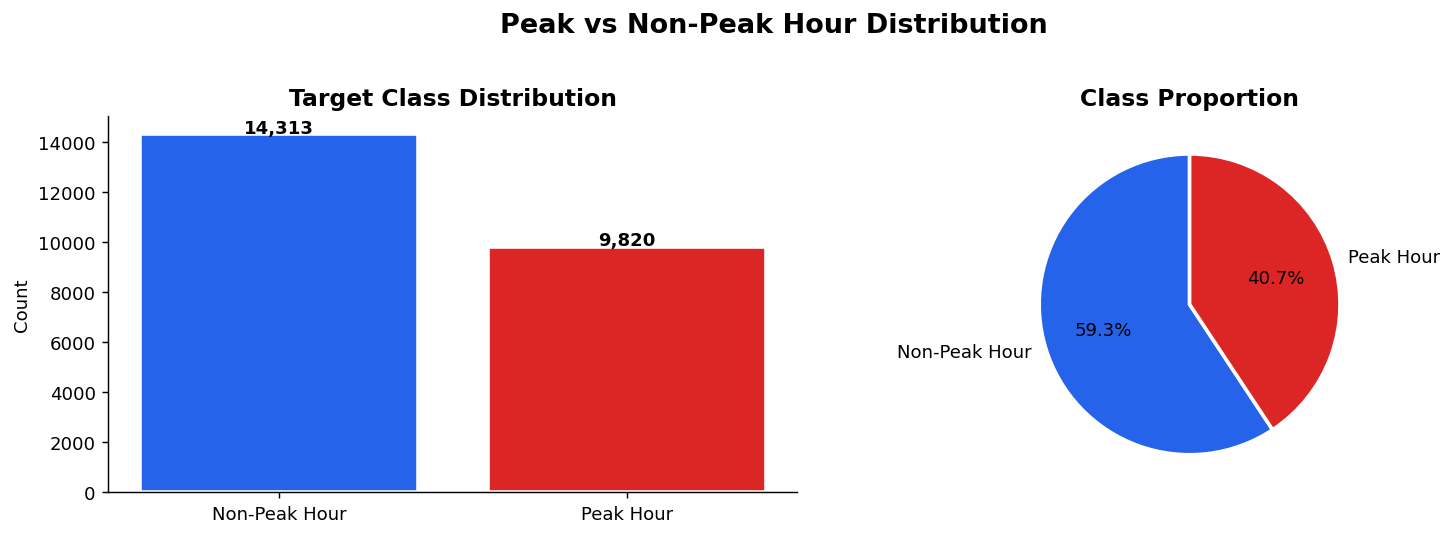

Saved → 01_class_distribution.png


In [9]:
#  4.2 Target Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['is_peak_hour'].value_counts()
labels = ['Non-Peak Hour', 'Peak Hour']

# Bar chart
bars = axes[0].bar(labels, counts.values, color=PALETTE, edgecolor='white', linewidth=2)
axes[0].set_title('Target Class Distribution', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=PALETTE, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontweight='bold', fontsize=13)

plt.suptitle('Peak vs Non-Peak Hour Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/01_class_distribution.png', bbox_inches='tight')
plt.show()
print('Saved → 01_class_distribution.png')

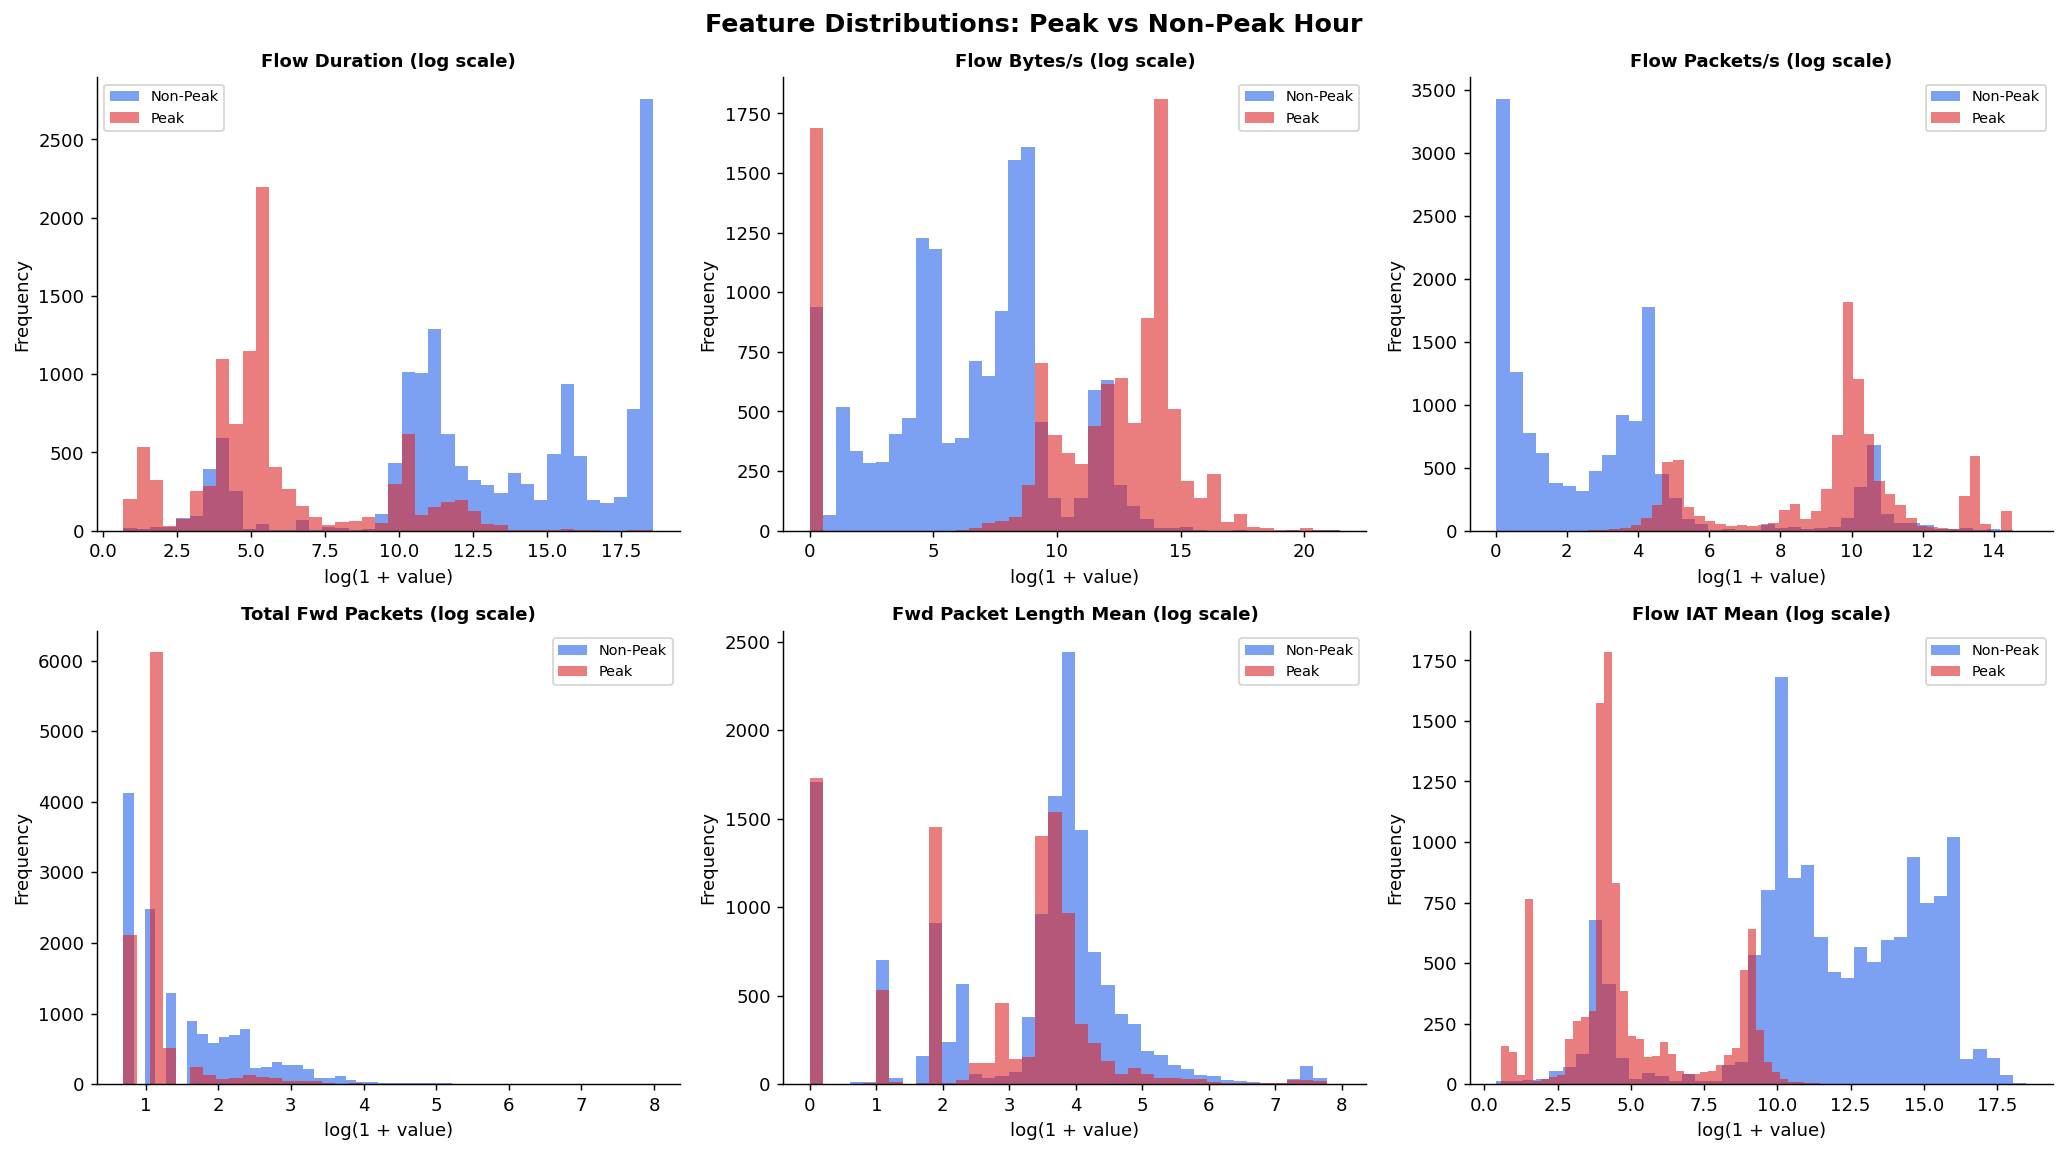

 Saved → 02_feature_distributions.png


In [10]:
#  4.3 Feature Distributions by Class 
PLOT_FEATURES = [
    c for c in [
        'Flow Duration', 'Flow Bytes/s', 'Flow Packets/s',
        'Total Fwd Packets', 'Fwd Packet Length Mean', 'Flow IAT Mean'
    ] if c in df.columns
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(PLOT_FEATURES):
    for cls, color, label in zip([0, 1], PALETTE, ['Non-Peak', 'Peak']):
        data = df.loc[df['is_peak_hour'] == cls, feat]
        # Use log-scale data for cleaner visualization
        data_log = np.log1p(data.clip(lower=0))
        axes[i].hist(data_log, bins=40, alpha=0.6, color=color, label=label, edgecolor='none')
    
    axes[i].set_title(f'{feat} (log scale)', fontweight='bold', fontsize=10)
    axes[i].set_xlabel('log(1 + value)')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions: Peak vs Non-Peak Hour', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_feature_distributions.png', bbox_inches='tight')
plt.show()
print(' Saved → 02_feature_distributions.png')

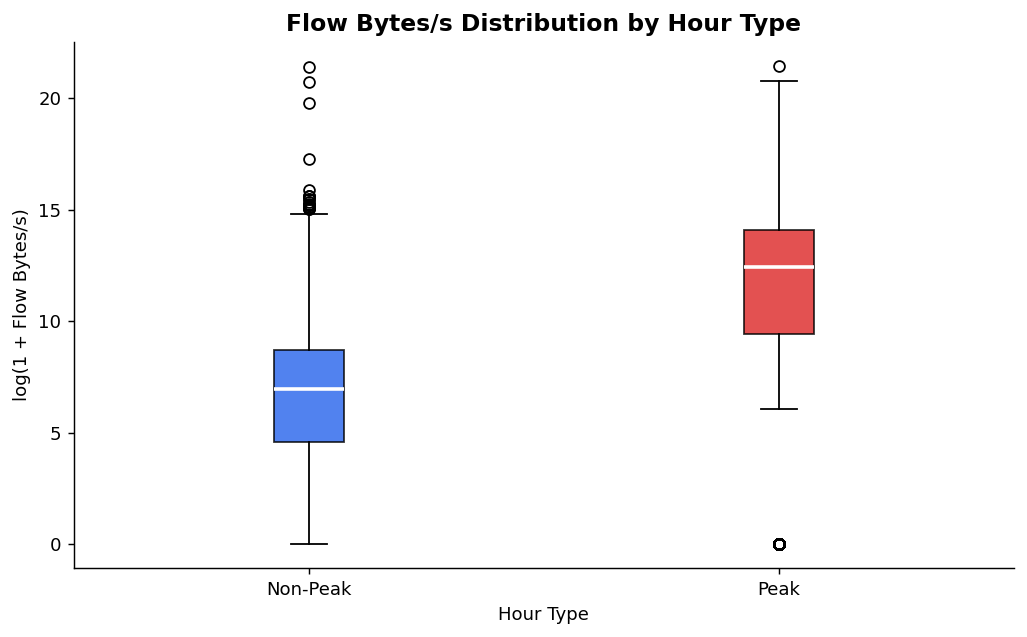

 Saved → 03_boxplot_bandwidth.png


In [11]:
#  4.4 Boxplot: Flow Bytes/s by Class 
if 'Flow Bytes/s' in df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    
    data_plot = [
        np.log1p(df.loc[df['is_peak_hour']==0, 'Flow Bytes/s'].clip(lower=0)),
        np.log1p(df.loc[df['is_peak_hour']==1, 'Flow Bytes/s'].clip(lower=0))
    ]
    
    bp = ax.boxplot(data_plot, patch_artist=True, labels=['Non-Peak', 'Peak'],
                    medianprops={'color': 'white', 'linewidth': 2})
    
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    
    ax.set_title('Flow Bytes/s Distribution by Hour Type', fontweight='bold', fontsize=13)
    ax.set_ylabel('log(1 + Flow Bytes/s)')
    ax.set_xlabel('Hour Type')
    
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/03_boxplot_bandwidth.png', bbox_inches='tight')
    plt.show()
    print(' Saved → 03_boxplot_bandwidth.png')

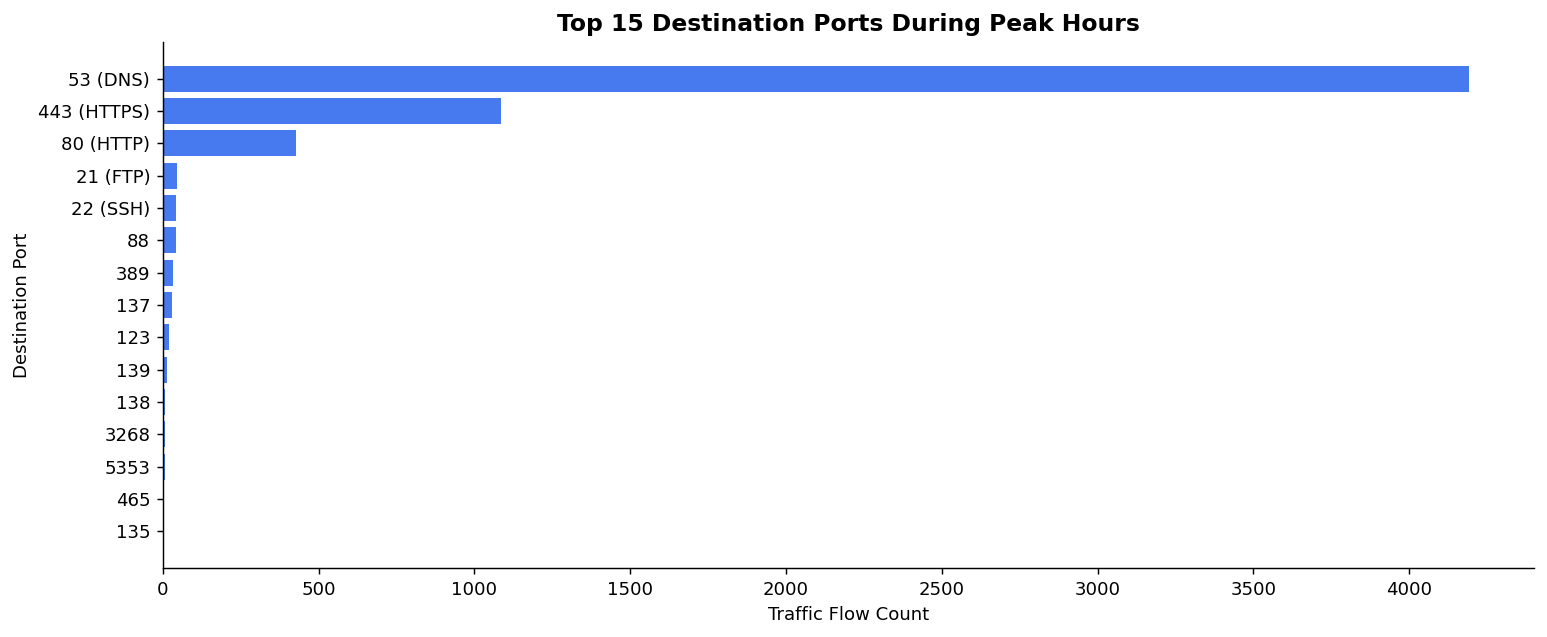

 Saved → 04_port_analysis.png


In [12]:
#  4.5 Port Analysis 
if 'Destination Port' in df.columns:
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Top 15 ports during peak hours
    peak_ports = df[df['is_peak_hour']==1]['Destination Port'].value_counts().head(15)
    
    bars = ax.barh(peak_ports.index.astype(str), peak_ports.values,
                   color='#2563EB', alpha=0.85)
    ax.set_title('Top 15 Destination Ports During Peak Hours', fontweight='bold', fontsize=13)
    ax.set_xlabel('Traffic Flow Count')
    ax.set_ylabel('Destination Port')
    ax.invert_yaxis()
    
    # Port labels
    port_names = {80:'HTTP', 443:'HTTPS', 22:'SSH', 21:'FTP', 53:'DNS',
                  8080:'HTTP-Alt', 25:'SMTP', 3306:'MySQL', 3389:'RDP'}
    ytick_labels = [
        f'{p} ({port_names.get(int(p), "")})'if str(p).isdigit() and int(p) in port_names else str(p)
        for p in peak_ports.index
    ]
    ax.set_yticklabels(ytick_labels)
    
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/04_port_analysis.png', bbox_inches='tight')
    plt.show()
    print(' Saved → 04_port_analysis.png')

---
## 5. Correlation Heatmap

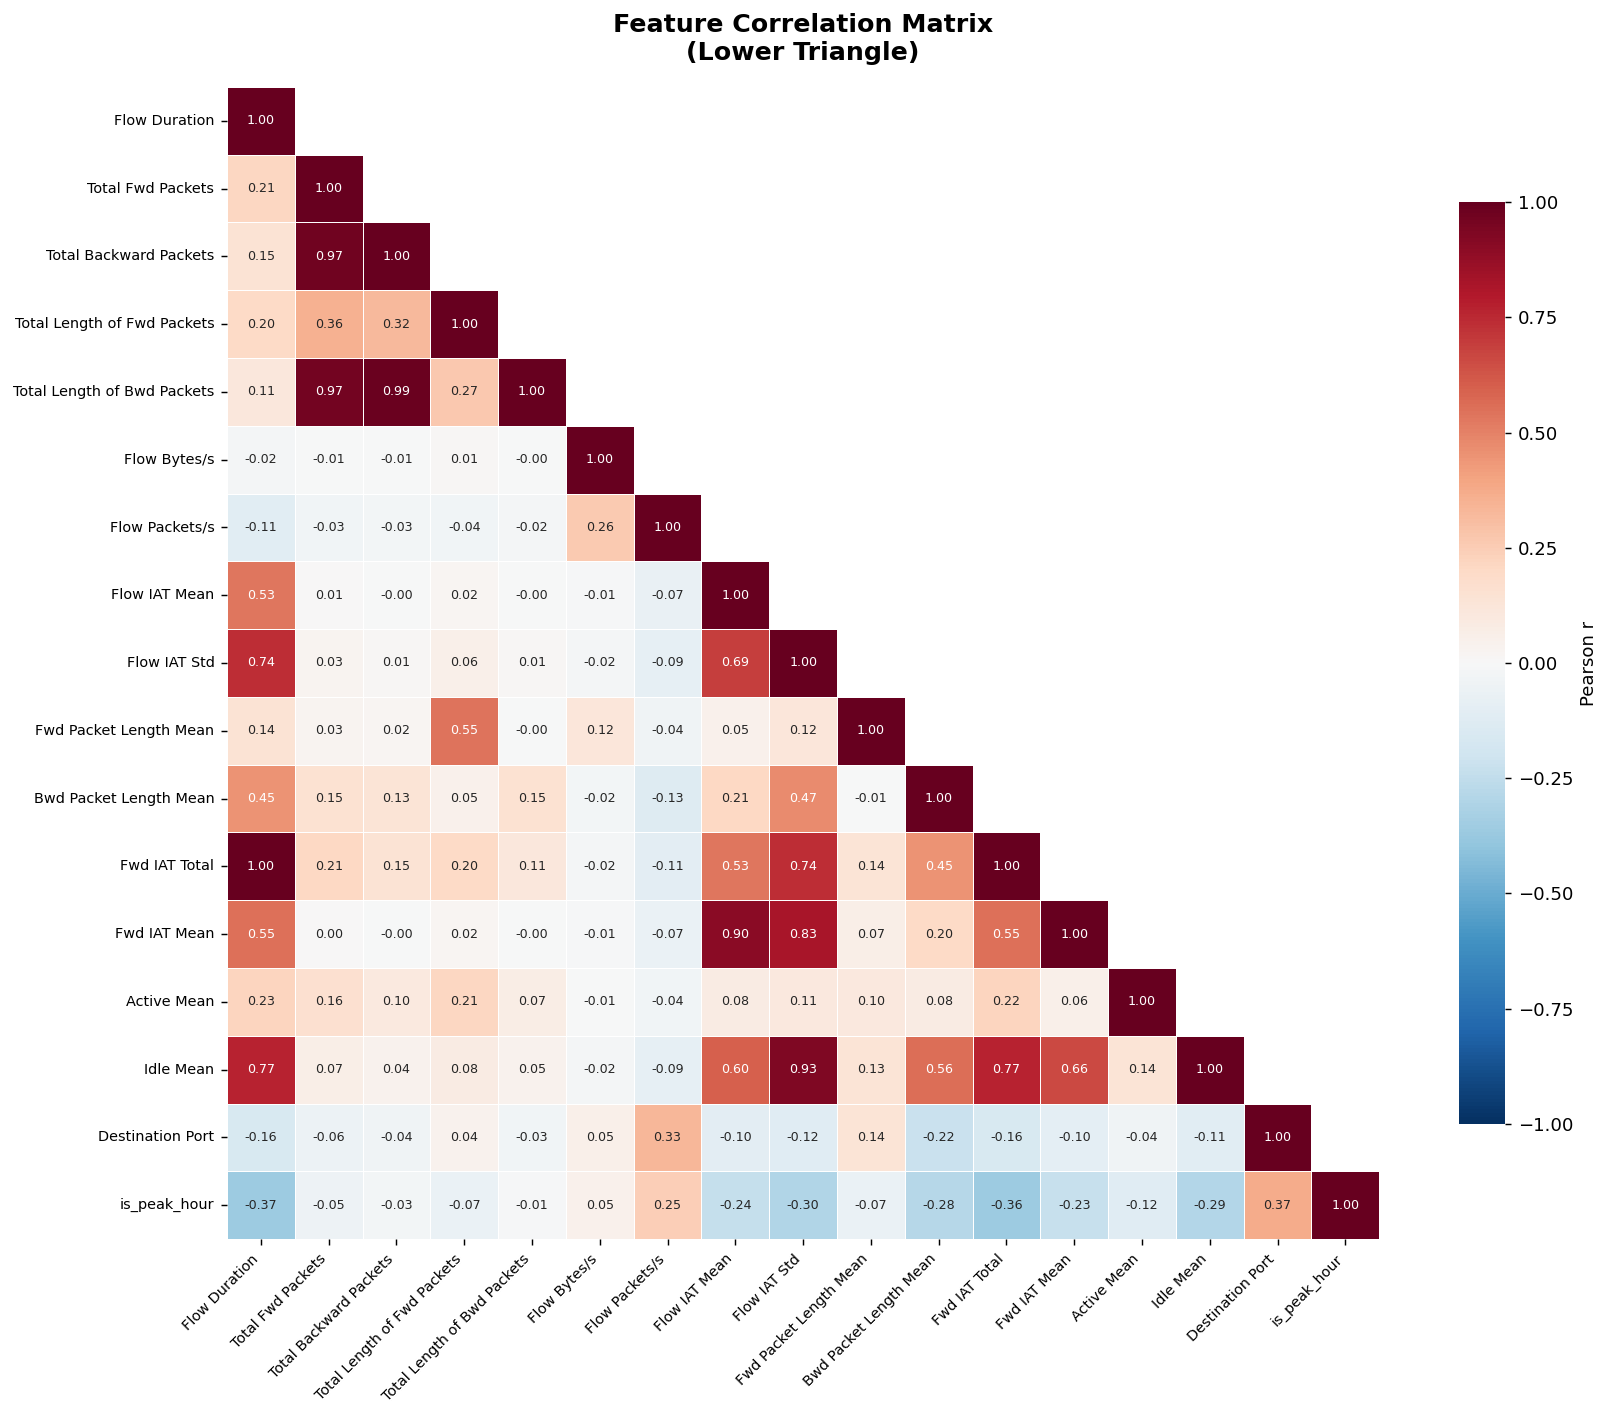

 Saved → 05_correlation_heatmap.png

 Top Feature Correlations with is_peak_hour:
Destination Port         0.3706
Flow Duration            0.3666
Fwd IAT Total            0.3602
Flow IAT Std             0.3037
Idle Mean                0.2938
Bwd Packet Length Mean   0.2834
Flow Packets/s           0.2489
Flow IAT Mean            0.2409
Fwd IAT Mean             0.2302
Active Mean              0.1212


In [13]:
# Use only original (non-log) numeric features for heatmap readability
orig_features = [c for c in df.columns if '_log' not in c and c != 'is_peak_hour']
corr_df = df[orig_features + ['is_peak_hour']].select_dtypes(include=np.number)

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(14, 11))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # upper triangle

sns.heatmap(
    corr_matrix,
    ax       = ax,
    mask     = mask,
    annot    = True,
    fmt      = '.2f',
    cmap     = 'RdBu_r',
    center   = 0,
    vmin     = -1, vmax = 1,
    square   = True,
    linewidths = 0.5,
    cbar_kws = {'shrink': 0.8, 'label': 'Pearson r'},
    annot_kws = {'size': 7}
)

ax.set_title('Feature Correlation Matrix\n(Lower Triangle)', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/05_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print(' Saved → 05_correlation_heatmap.png')

print('\n Top Feature Correlations with is_peak_hour:')
target_corr = corr_matrix['is_peak_hour'].drop('is_peak_hour').abs().sort_values(ascending=False)
print(target_corr.head(10).to_string())

---
## 6. Train / Test Split

In [14]:
#  Prepare X and y
TARGET = 'is_peak_hour'
FEATURE_COLS = [c for c in df.columns if c != TARGET]

X = df[FEATURE_COLS]
y = df[TARGET]

print(f' Feature matrix X: {X.shape}')
print(f' Target vector  y: {y.shape}')
print(f'\nFeatures used ({len(FEATURE_COLS)}):')
for i, col in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2}. {col}')

#  80/20 Stratified Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y       
)

print(f'\n Train set: {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f' Test  set: {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nTrain class balance: {dict(y_train.value_counts())}')
print(f'Test  class balance: {dict(y_test.value_counts())}')

 Feature matrix X: (24133, 27)
 Target vector  y: (24133,)

Features used (27):
   1. Flow Duration
   2. Total Fwd Packets
   3. Total Backward Packets
   4. Total Length of Fwd Packets
   5. Total Length of Bwd Packets
   6. Flow Bytes/s
   7. Flow Packets/s
   8. Flow IAT Mean
   9. Flow IAT Std
  10. Fwd Packet Length Mean
  11. Bwd Packet Length Mean
  12. Fwd IAT Total
  13. Fwd IAT Mean
  14. Active Mean
  15. Idle Mean
  16. Destination Port
  17. Flow Duration_log
  18. Total Fwd Packets_log
  19. Total Backward Packets_log
  20. Total Length of Fwd Packets_log
  21. Total Length of Bwd Packets_log
  22. Flow Bytes/s_log
  23. Flow Packets/s_log
  24. Fwd IAT Total_log
  25. Fwd IAT Mean_log
  26. Active Mean_log
  27. Idle Mean_log

 Train set: 19,306 rows (80%)
 Test  set: 4,827 rows (20%)

Train class balance: {0: np.int64(11450), 1: np.int64(7856)}
Test  class balance: {0: np.int64(2863), 1: np.int64(1964)}


---
## 7. Feature Scaling

In [15]:
# StandardScaler: zero mean, unit variance

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Save scaler for API use
scaler_path = os.path.join(MODEL_DIR, 'scaler.pkl')
joblib.dump(scaler, scaler_path)

print(f' StandardScaler fitted on training data')
print(f'   Train mean ≈ 0: {X_train_scaled.mean():.6f}')
print(f'   Train std  ≈ 1: {X_train_scaled.std():.6f}')
print(f' Scaler saved → {scaler_path}')

 StandardScaler fitted on training data
   Train mean ≈ 0: -0.000000
   Train std  ≈ 1: 1.000000
 Scaler saved → ../models\scaler.pkl


---
##  8. Train 5 Classification Models

| # | Model | Strengths for This Task |
|---|-------|-------------------------|
| 1 | Logistic Regression | Fast baseline, interpretable coefficients |
| 2 | Decision Tree | Visual rules, captures non-linearity |
| 3 | Random Forest | Robust ensemble, handles correlated features |
| 4 | Gradient Boosting | Sequential correction, high accuracy |
| 5 | XGBoost | State-of-the-art, fast, built-in regularization |

In [16]:
#  Model Definitions
MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0, solver='lbfgs', random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, min_samples_split=20, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=150, max_depth=10, n_jobs=-1, random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=150, learning_rate=0.1, max_depth=6,
        use_label_encoder=False, eval_metric='logloss',
        n_jobs=-1, random_state=42
    )
}

#  Training Loop
results = {}
trained_models = {}

print(' Training models...\n')
print(f'{"Model":<22} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print('-' * 65)

for name, model in MODELS.items():
    # Use scaled data for distance-based / linear models, original for tree models
    use_scaled = name in ['Logistic Regression']
    X_tr = X_train_scaled if use_scaled else X_train
    X_te = X_test_scaled  if use_scaled else X_test
    
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    
    results[name] = {
        'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1': f1,
        'y_pred': y_pred, 'use_scaled': use_scaled
    }
    trained_models[name] = model
    
    print(f'{name:<22} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}')

print('\n All models trained!')

 Training models...

Model                    Accuracy  Precision     Recall         F1
-----------------------------------------------------------------
Logistic Regression        0.9225     0.9211     0.8854     0.9029
Decision Tree              0.9901     0.9843     0.9913     0.9878
Random Forest              0.9932     0.9874     0.9959     0.9916
Gradient Boosting          0.9936     0.9909     0.9934     0.9921
XGBoost                    0.9940     0.9899     0.9954     0.9926

 All models trained!


---
## 9. Accuracy / Precision / Recall / F1 Comparison

 Model Performance Summary:
                     Accuracy  Precision  Recall  F1 Score
XGBoost                0.9940     0.9899  0.9954    0.9926
Gradient Boosting      0.9936     0.9909  0.9934    0.9921
Random Forest          0.9932     0.9874  0.9959    0.9916
Decision Tree          0.9901     0.9843  0.9913    0.9878
Logistic Regression    0.9225     0.9211  0.8854    0.9029


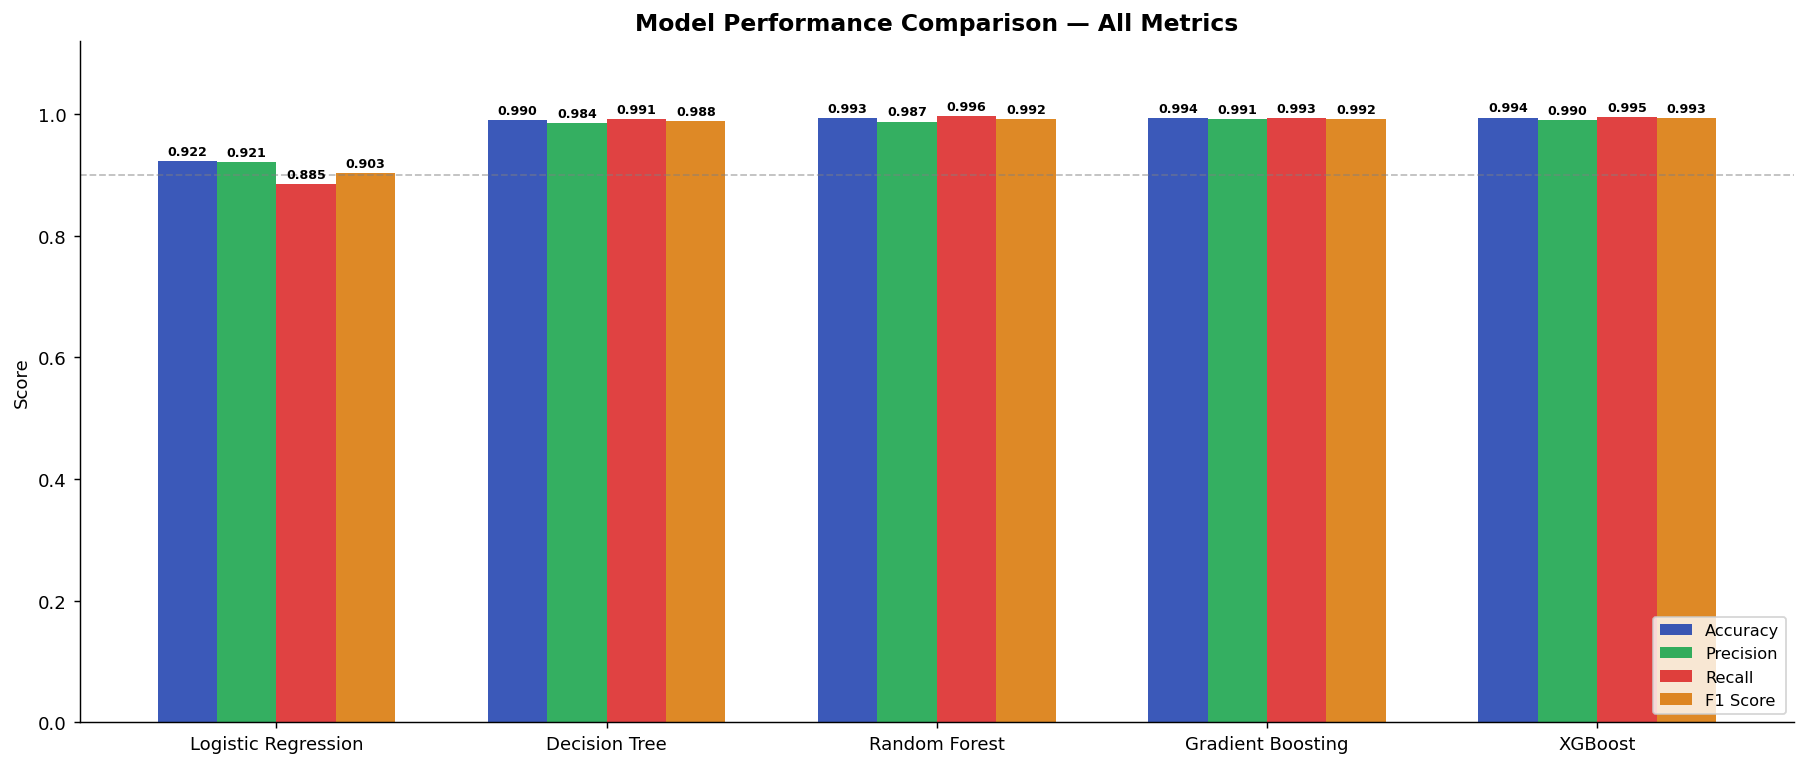

 Saved → 06_metrics_comparison.png


In [17]:
# Build metrics DataFrame 
metrics_df = pd.DataFrame({
    name: {
        'Accuracy' : v['Accuracy'],
        'Precision': v['Precision'],
        'Recall'   : v['Recall'],
        'F1 Score' : v['F1']
    }
    for name, v in results.items()
}).T.round(4)

print(' Model Performance Summary:')
print(metrics_df.sort_values('F1 Score', ascending=False).to_string())

# Grouped Bar Chart
fig, ax = plt.subplots(figsize=(14, 6))

x      = np.arange(len(metrics_df))
n_met  = 4
width  = 0.18
colors = ['#1E40AF', '#16A34A', '#DC2626', '#D97706']

for i, (metric, color) in enumerate(zip(metrics_df.columns, colors)):
    offset = (i - n_met/2 + 0.5) * width
    bars = ax.bar(x + offset, metrics_df[metric], width,
                  label=metric, color=color, alpha=0.87)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics_df.index, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — All Metrics', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.axhline(0.9, ls='--', color='gray', alpha=0.5, lw=1, label='90% threshold')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/06_metrics_comparison.png', bbox_inches='tight')
plt.show()
print(' Saved → 06_metrics_comparison.png')

---
##  10. Confusion Matrix for Each Model

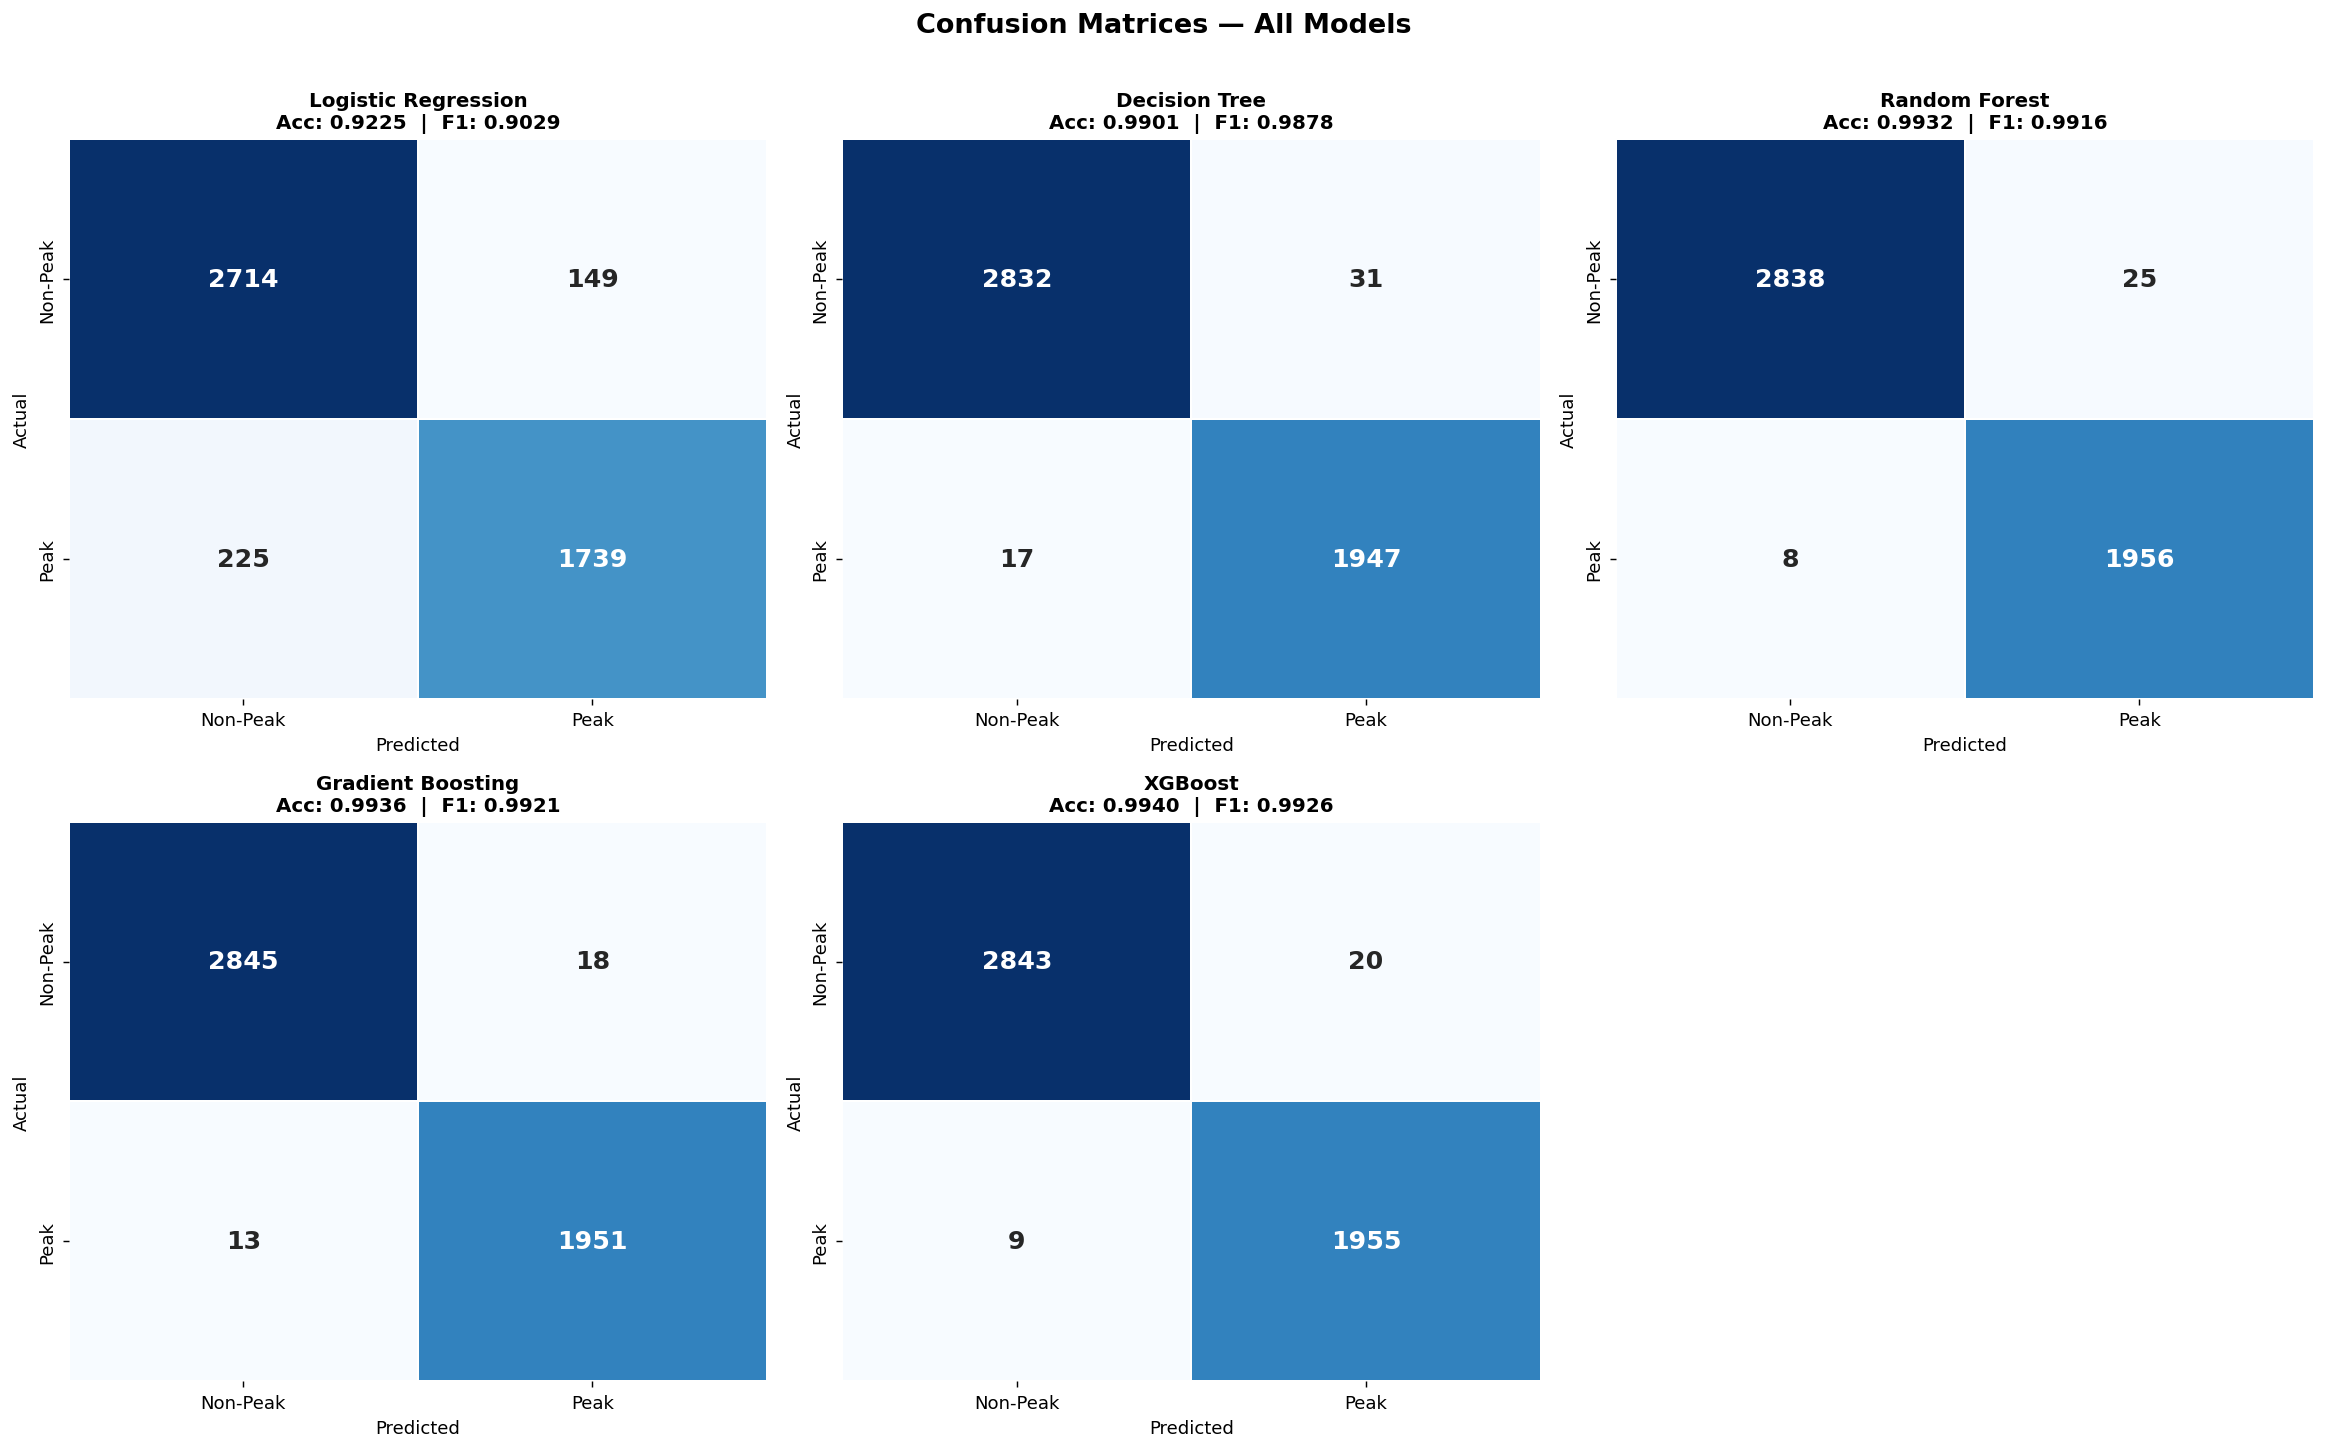

 Saved → 07_confusion_matrices.png


In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

class_labels = ['Non-Peak', 'Peak']

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    
    sns.heatmap(
        cm, ax=axes[i],
        annot=True, fmt='d',
        cmap='Blues',
        xticklabels=class_labels,
        yticklabels=class_labels,
        linewidths=1, linecolor='white',
        cbar=False, annot_kws={'size': 14, 'weight': 'bold'}
    )
    
    f1  = res['F1']
    acc = res['Accuracy']
    axes[i].set_title(f'{name}\nAcc: {acc:.4f}  |  F1: {f1:.4f}',
                      fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Actual', fontsize=10)
    axes[i].set_xlabel('Predicted', fontsize=10)

# Hide the last (6th) empty subplot
axes[-1].set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/07_confusion_matrices.png', bbox_inches='tight')
plt.show()
print(' Saved → 07_confusion_matrices.png')

---
## 11. Model Comparison Visualization

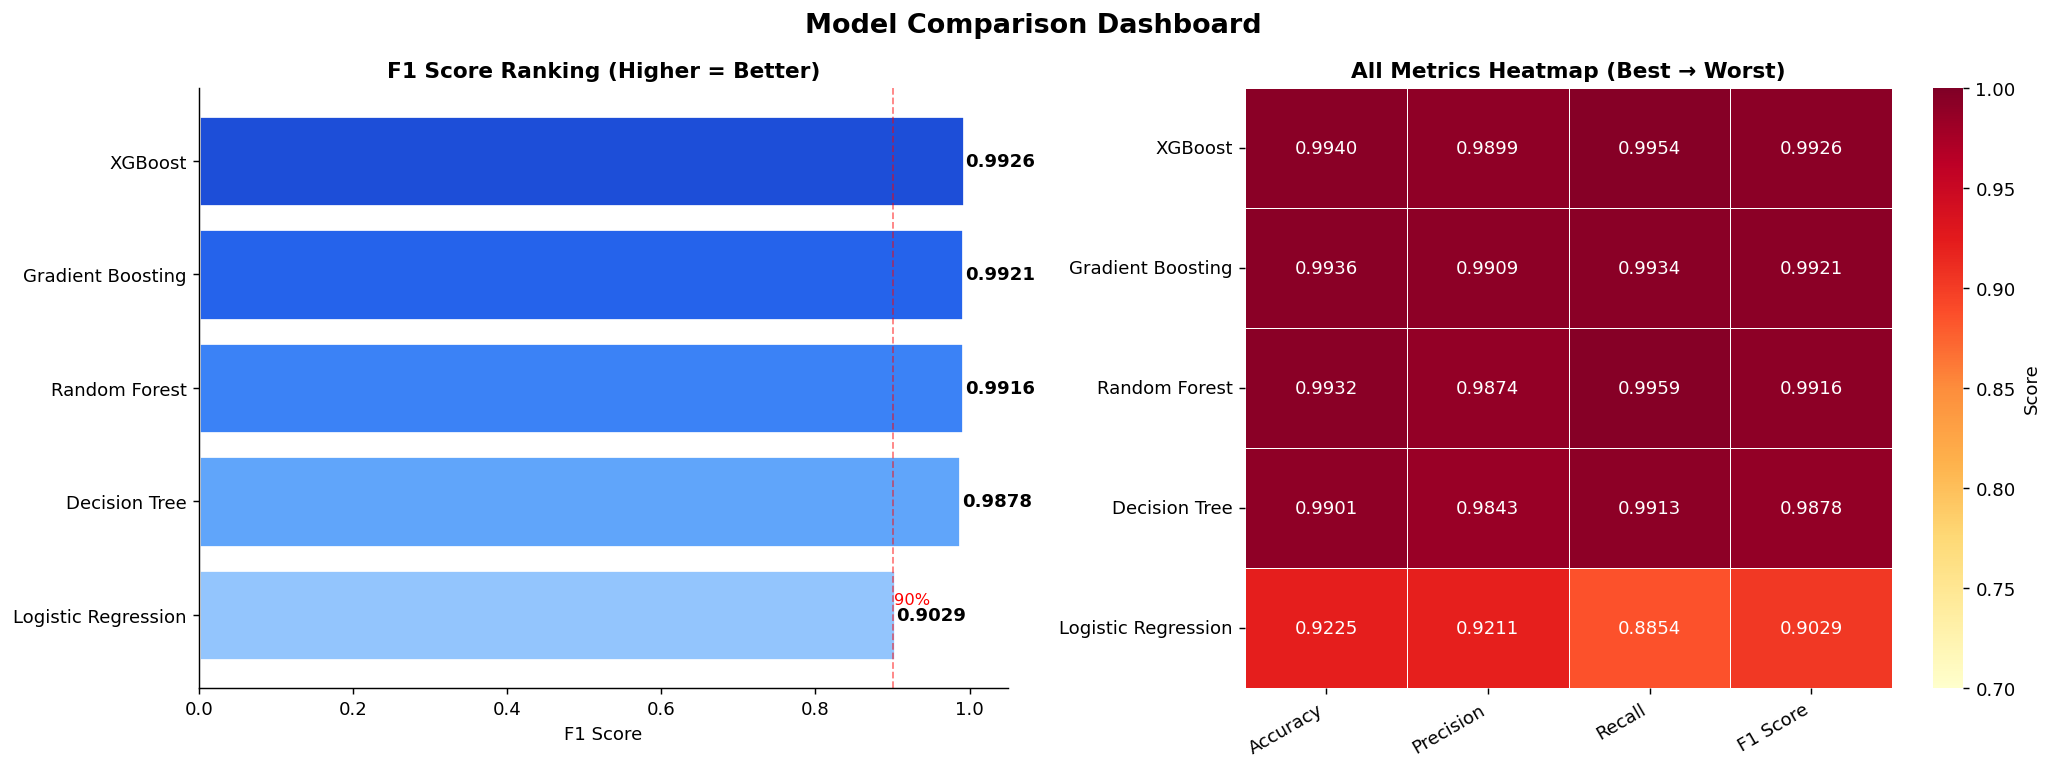

 Saved → 08_model_comparison.png


In [19]:
#  Radar Chart: Multi-metric comparison 
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

#  Left: F1 Score Ranking
f1_scores   = metrics_df['F1 Score'].sort_values(ascending=True)
bar_colors  = ['#93C5FD', '#60A5FA', '#3B82F6', '#2563EB', '#1D4ED8']

bars = ax1.barh(f1_scores.index, f1_scores.values,
                color=bar_colors, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, f1_scores.values):
    ax1.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontweight='bold', fontsize=10)

ax1.set_xlim(0, 1.05)
ax1.set_title('F1 Score Ranking (Higher = Better)', fontweight='bold', fontsize=12)
ax1.set_xlabel('F1 Score')
ax1.axvline(x=0.9, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax1.text(0.902, 0.1, '90%', color='red', fontsize=9)

#  Right: Heatmap of all metrics 
sns.heatmap(
    metrics_df.sort_values('F1 Score', ascending=False),
    ax=ax2, annot=True, fmt='.4f',
    cmap='YlOrRd', vmin=0.7, vmax=1.0,
    linewidths=0.5, cbar_kws={'label': 'Score'},
    annot_kws={'size': 10}
)
ax2.set_title('All Metrics Heatmap (Best → Worst)', fontweight='bold', fontsize=12)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30, ha='right')

plt.suptitle('Model Comparison Dashboard', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/08_model_comparison.png', bbox_inches='tight')
plt.show()
print(' Saved → 08_model_comparison.png')

---
## 12. Feature Importance Visualization

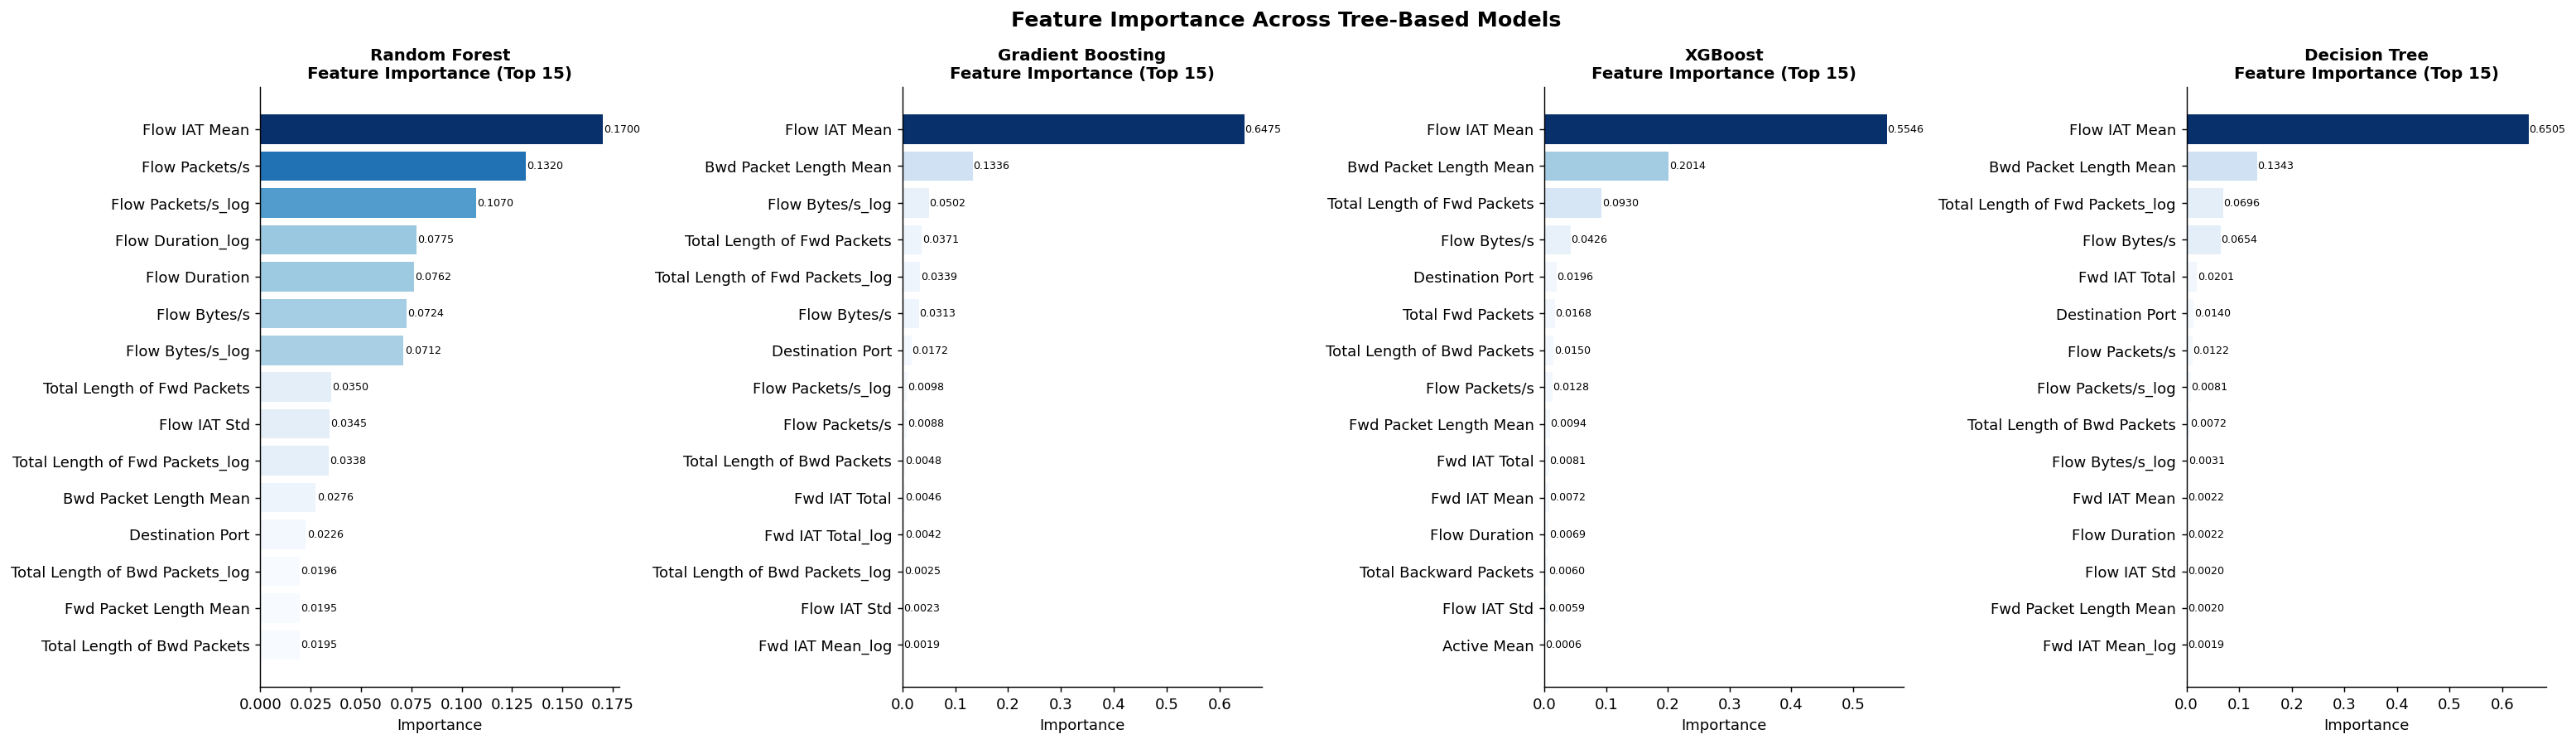

 Saved → 09_feature_importance.png


In [20]:
#  Tree-based models have built-in feature importances 
tree_models = ['Random Forest', 'Gradient Boosting', 'XGBoost', 'Decision Tree']
available_tree = [m for m in tree_models if m in trained_models]

fig, axes = plt.subplots(1, len(available_tree), figsize=(6*len(available_tree), 7))
if len(available_tree) == 1:
    axes = [axes]

for ax, name in zip(axes, available_tree):
    model      = trained_models[name]
    importances = model.feature_importances_
    feat_names  = FEATURE_COLS
    
    fi_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
    fi_df = fi_df.sort_values('Importance', ascending=True).tail(15)
    
    # Color by importance quartile
    norm = plt.Normalize(fi_df['Importance'].min(), fi_df['Importance'].max())
    colors = plt.cm.Blues(norm(fi_df['Importance'].values))
    
    bars = ax.barh(fi_df['Feature'], fi_df['Importance'], color=colors)
    ax.set_title(f'{name}\nFeature Importance (Top 15)', fontweight='bold', fontsize=11)
    ax.set_xlabel('Importance')
    
    for bar, val in zip(bars, fi_df['Importance']):
        ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=7)

plt.suptitle('Feature Importance Across Tree-Based Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/09_feature_importance.png', bbox_inches='tight')
plt.show()
print(' Saved → 09_feature_importance.png')

In [21]:
# Aggregate importance across all tree models
agg_importance = np.zeros(len(FEATURE_COLS))

for name in available_tree:
    agg_importance += trained_models[name].feature_importances_

agg_importance /= len(available_tree)  

agg_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Avg Importance': agg_importance})
agg_df = agg_df.sort_values('Avg Importance', ascending=False)

print(' Average Feature Importance (across all tree models):')
print(agg_df.to_string(index=False))

 Average Feature Importance (across all tree models):
                        Feature  Avg Importance
                  Flow IAT Mean          0.5056
         Bwd Packet Length Mean          0.1242
                   Flow Bytes/s          0.0529
    Total Length of Fwd Packets          0.0415
                 Flow Packets/s          0.0414
Total Length of Fwd Packets_log          0.0343
             Flow Packets/s_log          0.0312
               Flow Bytes/s_log          0.0311
                  Flow Duration          0.0217
              Flow Duration_log          0.0201
               Destination Port          0.0183
    Total Length of Bwd Packets          0.0116
                   Flow IAT Std          0.0112
                  Fwd IAT Total          0.0102
              Total Fwd Packets          0.0082
         Fwd Packet Length Mean          0.0081
Total Length of Bwd Packets_log          0.0055
                   Fwd IAT Mean          0.0054
               Fwd IAT Mean_log   

---
##  13. Best Model Selection

In [22]:
#  Select best model based on F1 Score 
best_name = metrics_df['F1 Score'].idxmax()
best_model = trained_models[best_name]
best_metrics = results[best_name]

print('=' * 55)
print('         BEST MODEL SELECTION  ')
print('=' * 55)
print(f'  Model     : {best_name}')
print(f'  Accuracy  : {best_metrics["Accuracy"]:.4f}')
print(f'  Precision : {best_metrics["Precision"]:.4f}')
print(f'  Recall    : {best_metrics["Recall"]:.4f}')
print(f'  F1 Score  : {best_metrics["F1"]:.4f}')
print('=' * 55)

#  Full classification report for best model 
print(f'\n Detailed Classification Report — {best_name}:')
print(classification_report(
    y_test, best_metrics['y_pred'],
    target_names=['Non-Peak', 'Peak']
))

#  Cross-validation for best model
use_scaled = best_metrics['use_scaled']
X_cv = X_train_scaled if use_scaled else X_train

cv_scores = cross_val_score(best_model, X_cv, y_train, cv=5, scoring='f1', n_jobs=-1)
print(f'\n 5-Fold Cross-Validation F1:')
print(f'   Scores : {cv_scores.round(4)}')
print(f'   Mean   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

         BEST MODEL SELECTION  
  Model     : XGBoost
  Accuracy  : 0.9940
  Precision : 0.9899
  Recall    : 0.9954
  F1 Score  : 0.9926

 Detailed Classification Report — XGBoost:
              precision    recall  f1-score   support

    Non-Peak       1.00      0.99      0.99      2863
        Peak       0.99      1.00      0.99      1964

    accuracy                           0.99      4827
   macro avg       0.99      0.99      0.99      4827
weighted avg       0.99      0.99      0.99      4827


 5-Fold Cross-Validation F1:
   Scores : [0.9952 0.9899 0.993  0.9936 0.9952]
   Mean   : 0.9934 ± 0.0020


---
##  14. Save Best Model for FastAPI

In [23]:
import json

#  Save the best model 
model_path = os.path.join(MODEL_DIR, 'best_model.pkl')
joblib.dump(best_model, model_path)
print(f' Best model saved  → {model_path}')

#  Save feature names list (for API input validation) 
feature_path = os.path.join(MODEL_DIR, 'feature_names.json')
with open(feature_path, 'w') as f:
    json.dump(FEATURE_COLS, f, indent=2)
print(f' Feature names saved → {feature_path}')

# Save model metadata 
metadata = {
    'model_name'       : best_name,
    'accuracy'         : round(best_metrics['Accuracy'], 4),
    'precision'        : round(best_metrics['Precision'], 4),
    'recall'           : round(best_metrics['Recall'], 4),
    'f1_score'         : round(best_metrics['F1'], 4),
    'features'         : FEATURE_COLS,
    'target'           : TARGET,
    'classes'          : {0: 'Non-Peak Hour', 1: 'Peak Hour'},
    'scaling_required' : best_metrics['use_scaled'],
    'sample_size'      : len(df),
    'dataset'          : 'CICIDS2017 (Canadian Institute for Cybersecurity)'
}
meta_path = os.path.join(MODEL_DIR, 'model_metadata.json')
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f' Metadata saved     → {meta_path}')

print('\n All artifacts saved successfully!')
print('\n Models directory contents:')
for f in os.listdir(MODEL_DIR):
    size = os.path.getsize(os.path.join(MODEL_DIR, f)) / 1024
    print(f'   {f:35s} ({size:.1f} KB)')

 Best model saved  → ../models\best_model.pkl
 Feature names saved → ../models\feature_names.json
 Metadata saved     → ../models\model_metadata.json

 All artifacts saved successfully!

 Models directory contents:
   best_model.pkl                      (344.3 KB)
   feature_names.json                  (0.7 KB)
   model_metadata.json                 (1.1 KB)
   scaler.pkl                          (2.0 KB)


---
## FastAPI Preview

In [24]:
# Quick local inference test 
print(' Quick Inference Test (simulating API call)\n')

# Load saved artifacts
loaded_model  = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)

# Sample from test set
sample_idx    = 42
sample_input  = X_test.iloc[[sample_idx]]
actual_label  = y_test.iloc[sample_idx]

# Apply scaling if required
if metadata['scaling_required']:
    sample_scaled = loaded_scaler.transform(sample_input)
    prediction    = loaded_model.predict(sample_scaled)[0]
    probability   = loaded_model.predict_proba(sample_scaled)[0]
else:
    prediction    = loaded_model.predict(sample_input)[0]
    probability   = loaded_model.predict_proba(sample_input)[0]

label_map = {0: '🟢 Non-Peak Hour', 1: '🔴 Peak Hour'}

print(f'  Input features  : {sample_input.shape}')
print(f'  Actual class    : {label_map[actual_label]}')
print(f'  Predicted class : {label_map[prediction]}')
print(f'  Confidence      : {max(probability)*100:.2f}%')
print(f'  Probabilities   : Non-Peak={probability[0]:.4f}, Peak={probability[1]:.4f}')
print(f'\n Model loaded and inference successful!')

 Quick Inference Test (simulating API call)

  Input features  : (1, 27)
  Actual class    : 🟢 Non-Peak Hour
  Predicted class : 🟢 Non-Peak Hour
  Confidence      : 100.00%
  Probabilities   : Non-Peak=1.0000, Peak=0.0000

 Model loaded and inference successful!


---
## 📝 Summary

| Step | Status |
|------|--------|
| ✅ Data Loading (CICIDS2017) | Complete |
| ✅ Data Cleaning | Complete |
| ✅ Feature Engineering & Target | Complete |
| ✅ EDA with visualizations | Complete |
| ✅ Correlation Heatmap | Complete |
| ✅ Train/Test Split (80/20) | Complete |
| ✅ Feature Scaling | Complete |
| ✅ 5 Models Trained | Complete |
| ✅ Metrics Comparison | Complete |
| ✅ Confusion Matrices | Complete |
| ✅ Feature Importance | Complete |
| ✅ Best Model Selected | Complete |
| ✅ Models Saved for FastAPI | Complete |